In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys
sys.path.insert(0, "/home/dajiang/smart-pixels-ml/two_bit_optimization_helpers") # Change this line to wherever the two_bit_optimization_helpers is located 
from prepare_tfrecords import load_tfrecords
from train import create_model, get_best_thresholds, cleanup_models_and_generators, get_all_losses, get_all_thresholds

In [7]:
weights_directory='/data/dajiang/smart-pixels/weights/dataset_3src_16x16_50x12P5_centeredIncidence_weights/'
train_type='soft_quantize_layer' # soft_quantize_layer or 2bit_optimized
model_type='Conv2D_Max'
timeslices=2
fingerprint='34c2da80'

train_losses, validation_losses = get_all_losses(f'{weights_directory}/weights-{timeslices}t-{model_type}-soft_quantize_layer-{fingerprint}-checkpoints')
epochs = np.arange(1, len(train_losses)+1, 1)

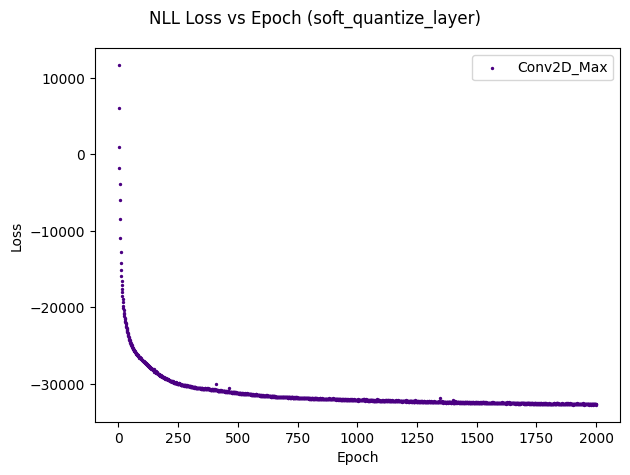

In [8]:
fig, ax = plt.subplots()

ax.scatter(x=epochs, y=validation_losses, s=2, c='indigo', label=model_type)

ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend()
fig.suptitle(f'NLL Loss vs Epoch ({train_type})')
fig.tight_layout()
fig.savefig(f'/home/dajiang/smart-pixels-ml/plots/loss/loss-{model_type}-{train_type}-{fingerprint}.png', dpi=300)
fig.show()

In [4]:
thresholds_1, thresholds_2, thresholds_3 = get_all_thresholds(
    f'{weights_directory}/weights-{timeslices}t-{model_type}-soft_quantize_layer-{fingerprint}-checkpoints',
    'Conv2D_Max',
    initial_thresholds=[247.8, 668.4, 1662.9],
    threshold_offset=80.0,
    initial_levels=np.array([0.0,1.0,2.0,3.0]),
    timeslices=2,
)

2025-11-23 17:08:01.619931: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3219 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB MIG 1g.5gb, pci bus id: 0000:c1:00.0, compute capability: 8.0
100%|██████████| 2000/2000 [00:15<00:00, 130.53it/s]


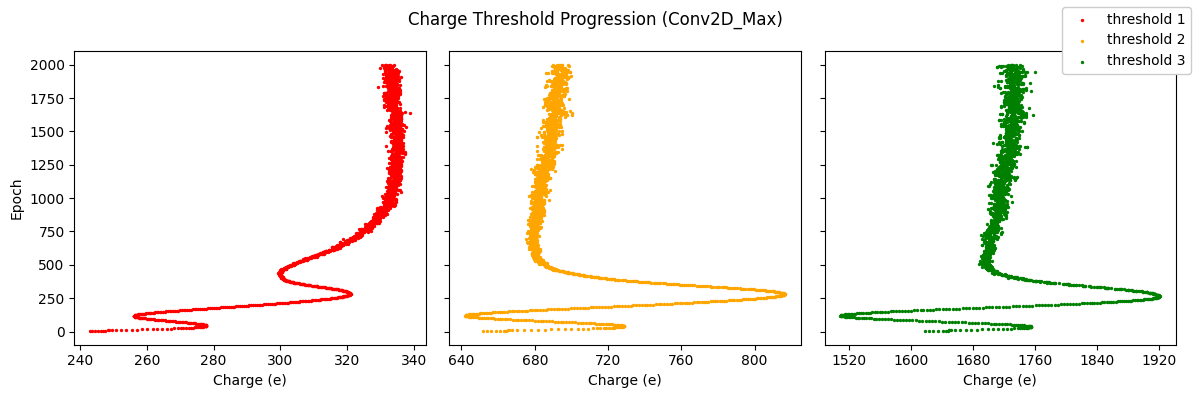

In [5]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
epochs=np.arange(1,len(thresholds_1)+1,1)
ax[0].scatter(x=thresholds_1, y=epochs, s=2, c='red', label='threshold 1')
ax[1].scatter(x=thresholds_2, y=epochs, s=2, c='orange', label='threshold 2')
ax[2].scatter(x=thresholds_3, y=epochs, s=2, c='green', label='threshold 3')

ax[0].set_ylabel('Epoch')

ax[0].set_xlabel('Charge (e)')
ax[1].set_xlabel('Charge (e)')
ax[2].set_xlabel('Charge (e)')

ax[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))
ax[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))
ax[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))

fig.legend(framealpha=1)
fig.suptitle(f'Charge Threshold Progression ({model_type})')
fig.tight_layout()
fig.savefig(f'/home/dajiang/smart-pixels-ml/plots/charge_threshold_progression/thresholds-{model_type}-{fingerprint}.png', dpi=300)
fig.show()